In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
data = pd.read_csv("student_performance_data.csv")

In [2]:
# PART A – DESCRIPTIVE ANALYTICS------------------------------------------------------------
# Descriptive analytics is used to summarize the dataset.
# In this part, we checked missing and duplicate values,
# generated summary statistics, and visualized distributions
# of Gender, Part-Time Job status, and GPA by Major and Gender.
# This helps understand overall student performance trends.
#-----------------------------------------------------------------------------------


# 1. Check Missing Values
print("Missing Values:\n", data.isnull().sum())

# 2. Check Duplicate Records
print("\nDuplicate Records:", data.duplicated().sum())

# 3. Summary Statistics
print("\nSummary Statistics:\n", data.describe().T)


Missing Values:
 StudentID                    0
Gender                       0
Age                          0
StudyHoursPerWeek            0
AttendanceRate               0
GPA                          0
Major                        0
PartTimeJob                  0
ExtraCurricularActivities    0
dtype: int64

Duplicate Records: 0

Summary Statistics:
                    count       mean         std    min       25%     50%  \
StudentID          500.0  250.50000  144.481833   1.00  125.7500  250.50   
Age                500.0   20.95600    2.000517  18.00   19.0000   21.00   
StudyHoursPerWeek  500.0   19.87600   11.471347   1.00   10.0000   20.50   
AttendanceRate     500.0   74.99038   14.565917  50.01   62.6075   75.73   
GPA                500.0    2.98516    0.563620   2.00    2.4875    3.00   

                      75%     max  
StudentID          375.25  500.00  
Age                 23.00   24.00  
StudyHoursPerWeek   30.00   39.00  
AttendanceRate      87.22   99.97  
GPA       

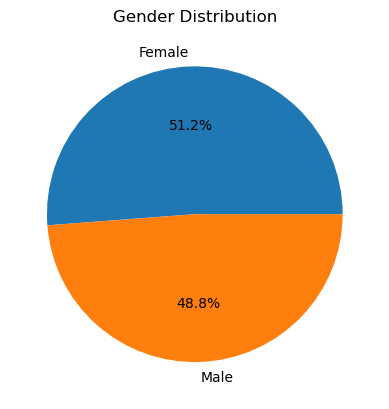

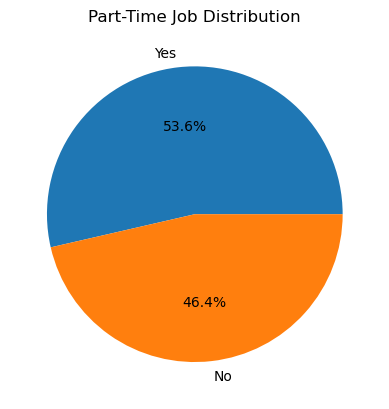

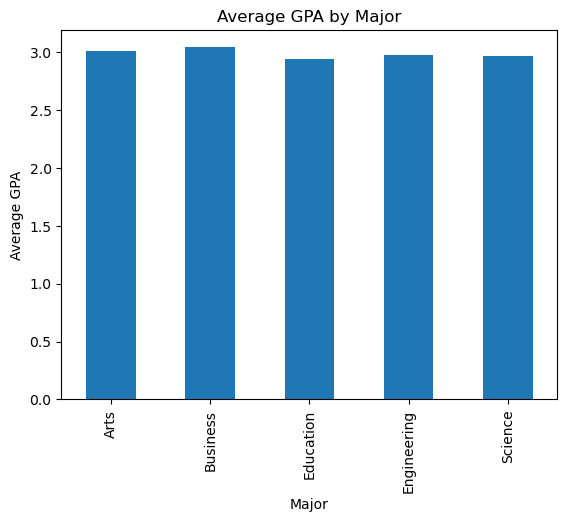

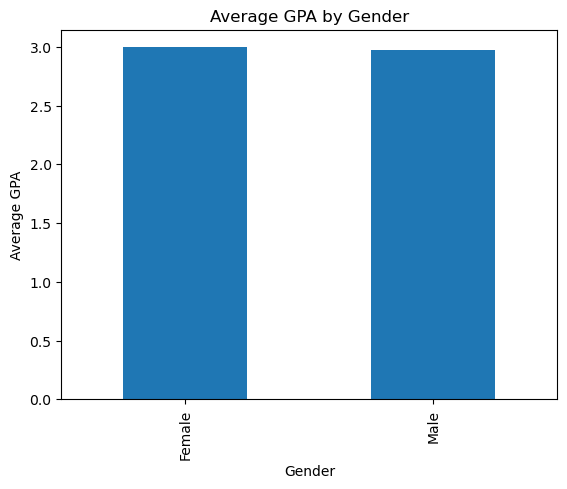

In [3]:
# 4. Gender Distribution (Pie Chart)
gender_counts = data['Gender'].value_counts()

plt.figure()
gender_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

# 5. Part-Time Job Distribution (Pie Chart)
job_counts = data['PartTimeJob'].value_counts()

plt.figure()
job_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Part-Time Job Distribution")
plt.ylabel("")
plt.show()

# 6. Average GPA by Major (Bar Chart)
gpa_major = data.groupby('Major')['GPA'].mean()

plt.figure()
gpa_major.plot(kind='bar')
plt.title("Average GPA by Major")
plt.ylabel("Average GPA")
plt.show()

# 7. Average GPA by Gender (Bar Chart)
gpa_gender = data.groupby('Gender')['GPA'].mean()

plt.figure()
gpa_gender.plot(kind='bar')
plt.title("Average GPA by Gender")
plt.ylabel("Average GPA")
plt.show()

Correlation Matrix:
                    StudentID       Age  StudyHoursPerWeek  AttendanceRate  \
StudentID           1.000000 -0.019205           0.017845       -0.033530   
Age                -0.019205  1.000000          -0.015695        0.037364   
StudyHoursPerWeek   0.017845 -0.015695           1.000000        0.095716   
AttendanceRate     -0.033530  0.037364           0.095716        1.000000   
GPA                -0.061763  0.095805           0.091700        0.060828   

                        GPA  
StudentID         -0.061763  
Age                0.095805  
StudyHoursPerWeek  0.091700  
AttendanceRate     0.060828  
GPA                1.000000  


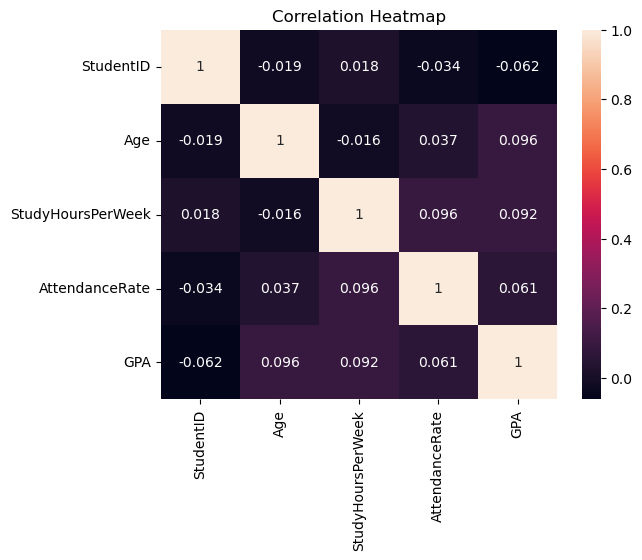

In [4]:
# PART B – DIAGNOSTIC ANALYTICS------------------------------------------
# Diagnostic analytics is used to identify reasons behind student performance.
# We analyzed correlation between numerical variables,
# compared GPA across attendance and study hour levels,
# and identified students with low GPA.
# This helps understand factors affecting academic performance.
#----------------------------------------------------------------------------

# 1. Correlation Matrix
correlation = data.corr(numeric_only=True)
print("Correlation Matrix:\n", correlation)

plt.figure()
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()






Average GPA by Attendance Level:
 AttendanceRate
(49.96, 66.663]     2.927089
(66.663, 83.317]    3.012732
(83.317, 99.97]     3.011132
Name: GPA, dtype: float64


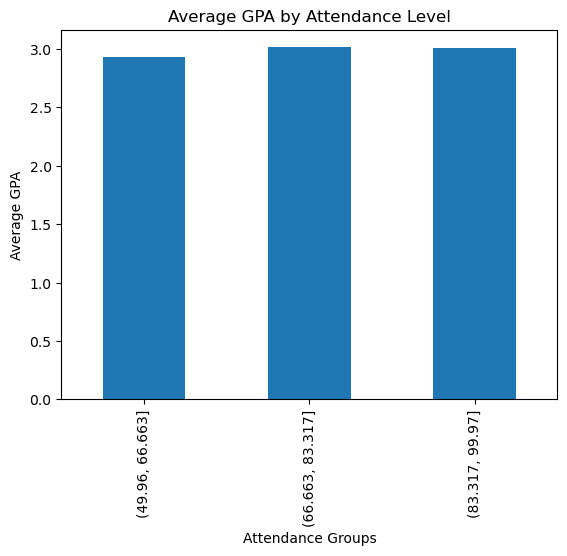

In [5]:
# 2. GPA by Attendance Level (Low / Medium / High)
gpa_attendance = data.groupby(
    pd.cut(data['AttendanceRate'], bins=3),
    observed=False
)['GPA'].mean()

print("\nAverage GPA by Attendance Level:\n", gpa_attendance)

plt.figure()
gpa_attendance.plot(kind='bar')
plt.title("Average GPA by Attendance Level")
plt.ylabel("Average GPA")
plt.xlabel("Attendance Groups")
plt.show()




Average GPA by Study Hours Level:
 StudyHoursPerWeek
(0.962, 13.667]     2.947941
(13.667, 26.333]    2.947636
(26.333, 39.0]      3.061030
Name: GPA, dtype: float64


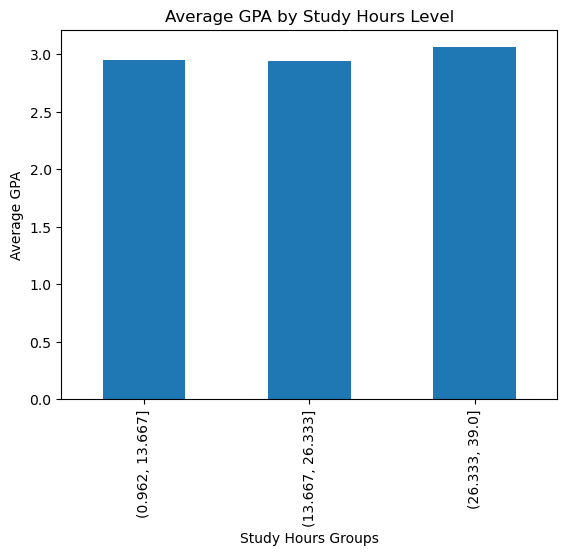

In [6]:

# 3. GPA by Study Hours Level (Low / Medium / High)
gpa_study = data.groupby(
    pd.cut(data['StudyHoursPerWeek'], bins=3),
    observed=False
)['GPA'].mean()

print("\nAverage GPA by Study Hours Level:\n", gpa_study)

plt.figure()
gpa_study.plot(kind='bar')
plt.title("Average GPA by Study Hours Level")
plt.ylabel("Average GPA")
plt.xlabel("Study Hours Groups")
plt.show()



In [7]:
# 4. Identify Low GPA Students
low_gpa_students = data[data['GPA'] < 2.5]

print("\nStudents with Low GPA (Below 2.5):")
print(low_gpa_students.head())


Students with Low GPA (Below 2.5):
    StudentID  Gender  Age  StudyHoursPerWeek  AttendanceRate   GPA  \
1           2  Female   22                 37           74.90  2.32   
2           3    Male   22                 10           53.36  2.38   
4           5    Male   18                 19           74.87  2.31   
5           6  Female   20                 17           86.01  2.47   
11         12    Male   19                  4           62.54  2.04   

        Major PartTimeJob ExtraCurricularActivities  
1   Education          No                        No  
2    Business          No                        No  
4   Education         Yes                        No  
5    Business         Yes                        No  
11    Science          No                       Yes  


In [8]:
#====================================================================================================
# PART C – PREDICTIVE ANALYTICS
# This part builds a predictive model to estimate student GPA.
# The model uses study hours per week and attendance rate as input factors.
# Linear regression is applied to predict future GPA values.
# Model performance is measured using R² score and MAE.

#=======================================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Load Dataset
data = pd.read_csv("student_performance_data.csv")


# 1. Select Important Features (Better Prediction)
X = data[['StudyHoursPerWeek', 'AttendanceRate']]
y = data['GPA']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predictions
y_pred = model.predict(X_test)

# 5. Model Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("MAE:", mae)

# 6. Predict GPA for New Student
# Example: 10 study hours & 85% attendance
new_student = pd.DataFrame(
    [[10, 85]],
    columns=['StudyHoursPerWeek', 'AttendanceRate']
)

future_gpa = model.predict(new_student)
print("Predicted GPA:", round(future_gpa[0], 2))


R² Score: 0.012785616552193013
MAE: 0.5265066171459006
Predicted GPA: 2.96


In [9]:
# MAE (Mean Absolute Error):
# Shows the average difference between predicted GPA and actual GPA values.

# R² Score:
# Indicates how well the selected factors explain the variation in GPA.

#-----------------------------------------------------------------------------------------

# Effect of MAE:
# Lower MAE means the predicted GPA is closer to the actual GPA, improving prediction accuracy.

# Effect of R²:
# Higher R² means the model explains GPA variation better, indicating a stronger and more reliable model.


In [10]:
# Part C – Predictive Analytics (Advanced Model)========================================================
# This model predicts student GPA using academic and personal factors.
# Feature scaling is applied to normalize input data for fair contribution.
# Ridge regression is used to reduce overfitting and improve generalization.
# Model performance is evaluated using R² score and MAE.

# – ADVANCED IMPROVED MODEL

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

# Load Dataset
data = pd.read_csv("student_performance_data.csv")

# Encode categorical values
data['PartTimeJob'] = data['PartTimeJob'].map({'Yes': 1, 'No': 0})
data['ExtraCurricularActivities'] = data['ExtraCurricularActivities'].map({'Yes': 1, 'No': 0})

# Features & Target
X = data[
    ['StudyHoursPerWeek',
     'AttendanceRate',
     'Age',
     'PartTimeJob',
     'ExtraCurricularActivities']
]
y = data['GPA']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline: Scaling + Ridge Regression
model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Optimized R² Score:", r2)
print("Optimized MAE:", mae)

# New student prediction
"""
[
 StudyHoursPerWeek,          # 10  → Hours studied per week
 AttendanceRate,             # 85  → Attendance percentage
 Age,                        # 20  → Student age in years
 PartTimeJob,                # 0   → 0 = No, 1 = Yes
 ExtraCurricularActivities   # 1   → 0 = No, 1 = Yes
]

"""
new_student = pd.DataFrame(
    [[2,85,20,1,1]],
    columns=X.columns
)

predicted_gpa = model.predict(new_student)
print("Predicted GPA:", round(predicted_gpa[0], 2))


Optimized R² Score: 0.03951399942251965
Optimized MAE: 0.5200403345398469
Predicted GPA: 2.92


In [11]:
# ------------------------------------
# PART D – PRESCRIPTIVE ANALYTICS

# Prescriptive analytics generates recommendations mainly based on
# the predicted GPA outcome and further analyzes influencing factors.

#(extra working fector)----------------------------
# Default recommendation ensures meaningful output
# even when no critical risk factors are found.

#=======================================================
predicted_gpa = predicted_gpa[0]

study_hours = new_student['StudyHoursPerWeek'].values[0]
attendance = new_student['AttendanceRate'].values[0]
part_time_job = new_student['PartTimeJob'].values[0]
activities = new_student['ExtraCurricularActivities'].values[0]

print("Predicted GPA:", round(predicted_gpa, 2))

recommendations = []

#PRIMARY DECISION BASED ON PREDICTION 
if predicted_gpa < 3.5:

    if predicted_gpa < 2.5:
        recommendations.append(
            "Immediate academic intervention and structured study plan required."
        )

    if attendance < 50:
        recommendations.append(
            "Improve attendance to strengthen academic consistency."
        )

    if study_hours < 10:
        recommendations.append(
            "Increase weekly study hours to improve learning outcomes."
        )

    if part_time_job == 1:
        recommendations.append(
            "Better balance part-time job commitments with studies."
        )

    if activities == 0:
        recommendations.append(
            "Participate in extracurricular activities to improve engagement."
        )

# DEFAULT RECOMMENDATION (IMPORTANT)
    if len(recommendations) == 0:
        recommendations.append(
            "Maintain current study routine and focus on improving weak subjects."
        )

else:
    recommendations.append(
        "Predicted performance is strong. Continue the current academic strategy."
    )

# Display recommendations
print("Recommendations:")
for r in recommendations:
    print("-", r)


Predicted GPA: 2.92
Recommendations:
- Increase weekly study hours to improve learning outcomes.
- Better balance part-time job commitments with studies.
